# Spam Detector — End-to-End NLP Pipeline

**Dataset:** `spam_ham_dataset.csv`  
**Task:** Binary text classification — `spam` vs `ham`  
**Method:** TF-IDF vectorisation + classical ML classifiers  

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Load & Inspect Data](#2-load--inspect-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Text Preprocessing](#4-text-preprocessing)
5. [Train/Test Split](#5-traintest-split)
6. [Model Comparison (Cross-Validation)](#6-model-comparison-cross-validation)
7. [Final Evaluation on Test Set](#7-final-evaluation-on-test-set)
8. [Save Model Artefacts](#8-save-model-artefacts)
9. [Inference — Predict New Emails](#9-inference--predict-new-emails)


> **Reproducibility:** All random operations use `RANDOM_STATE = 42`.

## 1. Setup & Imports

In [ ]:
#  Standard library 
import re
import time
import warnings
from collections import Counter
from pathlib import Path

# Data & ML 
import joblib
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# NLTK resources (idempotent) 
for resource, path in [("stopwords", "corpora/stopwords"), ("wordnet", "corpora/wordnet")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

#  Global constants 
DATASET_PATH = Path("../spam_ham_dataset.csv")
MODELS_DIR   = Path("../models")
MODEL_PATH   = MODELS_DIR / "spam_detector_model.pkl"
RANDOM_STATE = 42
TEST_SIZE    = 0.25

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Plot style 
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

SPAM_COLOR = "#E63946"
HAM_COLOR  = "#457B9D"

print("Environment ready.")

Environment ready.


## 2. Load & Inspect Data

In [21]:
df_raw = pd.read_csv(DATASET_PATH)

# Keep only the two columns we need; drop any artefact columns
df = df_raw[["label", "text"]].copy()

print(f"Shape: {df.shape}")
print(f"\nLabel distribution:")
print(df["label"].value_counts(normalize=True).map("{:.1%}".format).to_string())
print(f"\nMissing values:")
print(df.isnull().sum().to_string())
df.head()

Shape: (5171, 2)

Label distribution:
label
ham     71.0%
spam    29.0%

Missing values:
label    0
text     0


,label,text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


In [22]:
# Basic text statistics per class
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df.groupby("label")[["char_count", "word_count"]].agg(["mean", "median"]).round(1)

char_count        word_count       
            mean median       mean median
label                                    
ham        977.0  530.0      225.2  123.0
spam      1223.3  576.0      234.1  114.0

## 3. Exploratory Data Analysis (EDA)

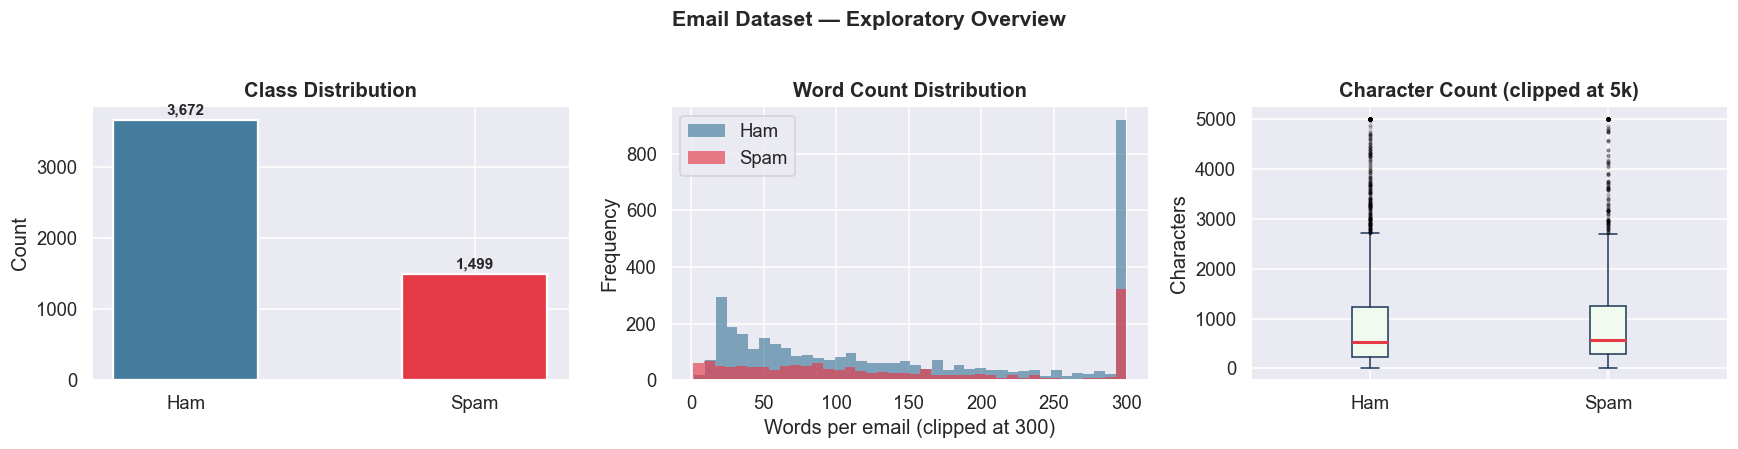

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 3a. Class balance
counts = df["label"].value_counts()
axes[0].bar(["Ham", "Spam"], [counts["ham"], counts["spam"]],
            color=[HAM_COLOR, SPAM_COLOR], width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, [counts["ham"], counts["spam"]]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# 3b. Word count distribution
for label, color in [("ham", HAM_COLOR), ("spam", SPAM_COLOR)]:
    data = df.loc[df["label"] == label, "word_count"].clip(upper=300)
    axes[1].hist(data, bins=40, alpha=0.65, color=color, label=label.capitalize(), edgecolor="none")
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words per email (clipped at 300)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# 3c. Character count box plot
ham_chars  = df.loc[df["label"] == "ham",  "char_count"].clip(upper=5000)
spam_chars = df.loc[df["label"] == "spam", "char_count"].clip(upper=5000)
axes[2].boxplot([ham_chars, spam_chars], labels=["Ham", "Spam"],
                patch_artist=True,
                boxprops=dict(facecolor="#F1FAEE", color="#1D3557"),
                medianprops=dict(color="#E63946", linewidth=2),
                whiskerprops=dict(color="#1D3557"),
                capprops=dict(color="#1D3557"),
                flierprops=dict(marker=".", alpha=0.3, markersize=3))
axes[2].set_title("Character Count (clipped at 5k)", fontweight="bold")
axes[2].set_ylabel("Characters")

fig.suptitle("Email Dataset — Exploratory Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

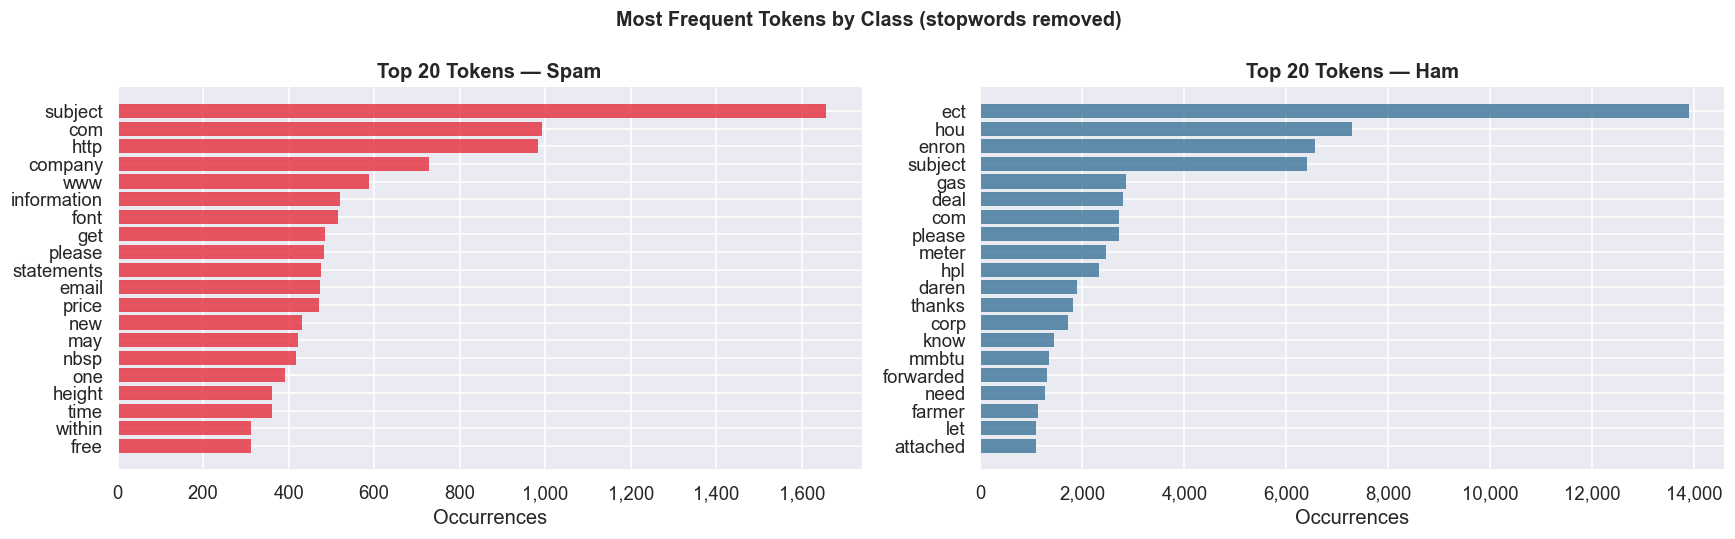

In [24]:
# Top tokens per class (quick, before stemming)
_stop_words_eda = set(stopwords.words("english"))

def top_tokens(texts: pd.Series, n: int = 20) -> pd.DataFrame:
    tokens = (
        texts.str.lower()
             .str.replace(r"[^a-z\s]", " ", regex=True)
             .str.split()
             .explode()
    )
    tokens = tokens[~tokens.isin(_stop_words_eda) & (tokens.str.len() > 2)]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["token", "count"])

top_spam = top_tokens(df.loc[df["label"] == "spam", "text"])
top_ham  = top_tokens(df.loc[df["label"] == "ham",  "text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, data, color, title in [
    (axes[0], top_spam, SPAM_COLOR, "Top 20 Tokens — Spam"),
    (axes[1], top_ham,  HAM_COLOR,  "Top 20 Tokens — Ham"),
]:
    ax.barh(data["token"][::-1], data["count"][::-1], color=color, edgecolor="none", alpha=0.85)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Occurrences")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Most Frequent Tokens by Class (stopwords removed)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

**Pipeline:**
1. Lowercase
2. Remove special characters — **digits are kept** (`"100%"`, `"1-800"` are discriminative for spam)
3. Remove English stopwords
4. Porter Stemming (fast, effective for bag-of-words classification)

`preprocess_text` is a **pure function**: no side-effects, safe to serialise and parallelise.

In [25]:
# Module-level singletons — instantiated once, reused across all calls
_STOP_WORDS = frozenset(stopwords.words("english"))
_STEMMER    = PorterStemmer()
_SYMBOL_RE  = re.compile(r"[^a-z0-9\s]")


def preprocess_text(text: str) -> str:
    """Clean and stem a single email string.

    Returns an empty string for non-string or blank inputs.
    Digits are intentionally kept: '100%', '1800' are
    discriminative features for spam detection.
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = _SYMBOL_RE.sub(" ", text)
    tokens = [
        _STEMMER.stem(t)
        for t in text.split()
        if t not in _STOP_WORDS
    ]
    return " ".join(tokens)


# Smoke test
examples = [
    "Congratulations! You've WON a FREE iPhone 100% guaranteed!",
    "Hi Sarah, please find the Q3 report attached. Kind regards.",
]
for raw in examples:
    print(f"IN : {raw}")
    print(f"OUT: {preprocess_text(raw)}")
    print()

IN : Congratulations! You've WON a FREE iPhone 100% guaranteed!
OUT: congratul free iphon 100 guarante

IN : Hi Sarah, please find the Q3 report attached. Kind regards.
OUT: hi sarah pleas find q3 report attach kind regard



In [26]:
print("Preprocessing text...", end=" ")
t0 = time.perf_counter()
df["clean_text"] = df["text"].apply(preprocess_text)
print(f"done in {time.perf_counter() - t0:.1f}s")

# Encode labels: spam=1, ham=0
df["label_num"] = (df["label"] == "spam").astype(int)

df[["label", "text", "clean_text"]].sample(3, random_state=RANDOM_STATE)

Preprocessing text... done in 6.0s


,label,text,clean_text
1566,ham,"Subject: hpl nom for march 30 , 2001\r\n( see ...",subject hpl nom march 30 2001 see attach file ...
1988,spam,Subject: online pharxmacy 80 % off all meds\r\...,subject onlin pharxmaci 80 med disscount phafr...
1235,ham,Subject: re : nom / actual volume for april 17...,subject nom actual volum april 17 th agre eile...


## 5. Train/Test Split

- **75 % training / 25 % test** 
- `stratify=y` preserves the spam/ham ratio in both partitions  
- The **test set is locked** — untouched until Section 7

In [27]:
X = df["clean_text"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training : {len(X_train):,} samples  ({y_train.mean():.1%} spam)")
print(f"Test     : {len(X_test):,} samples  ({y_test.mean():.1%} spam)")

# Duplicate check: same text in both splits inflates metrics
cross_split_dups = set(X_train) & set(X_test)
if cross_split_dups:
    print(f"\nWARNING: {len(cross_split_dups)} identical texts in both train and test — metrics may be slightly optimistic.")
else:
    print("\nNo cross-split duplicates found.")

Training : 3,878 samples  (29.0% spam)
Test     : 1,293 samples  (29.0% spam)



## 6. Model Comparison (Cross-Validation)

Four classifiers evaluated with **5-fold Stratified CV on the training set only**.

| Model | Notes |
|---|---|
| `MultinomialNB` | Classic baseline for text; fast |
| `ComplementNB` | Better than MNB on imbalanced classes |
| `LogisticRegression` | Well-calibrated probabilities |
| `LinearSVC` | Often highest performer on sparse TF-IDF features |

**Primary metric: F1-spam.** Accuracy alone misleads when classes are imbalanced.

In [28]:
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=50_000,
)

CLASSIFIERS = {
    "MultinomialNB":      MultinomialNB(),
    "ComplementNB":       ComplementNB(),
    "LogisticRegression": LogisticRegression(
        max_iter=1_000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "LinearSVC": LinearSVC(
        max_iter=2_000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = dict(
    f1_spam="f1",
    precision_spam="precision",
    recall_spam="recall",
    roc_auc="roc_auc",
    accuracy="accuracy",
)

cv_records = []
print(f"{'Model':<22} {'F1-spam':>8}  {'±':>6}  {'ROC-AUC':>8}  {'Recall':>7}  {'Acc':>7}  {'Time':>6}")
print("-" * 75)

for name, clf in CLASSIFIERS.items():
    pipeline = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_PARAMS)), ("clf", clf)])
    t0 = time.perf_counter()
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    elapsed = time.perf_counter() - t0

    row = {
        "Model":     name,
        "F1-spam":   scores["test_f1_spam"].mean(),
        "F1-std":    scores["test_f1_spam"].std(),
        "Recall":    scores["test_recall_spam"].mean(),
        "Precision": scores["test_precision_spam"].mean(),
        "ROC-AUC":   scores["test_roc_auc"].mean(),
        "Accuracy":  scores["test_accuracy"].mean(),
        "Time(s)":   round(elapsed, 1),
    }
    cv_records.append(row)
    print(f"{name:<22} {row['F1-spam']:>8.4f}  {row['F1-std']:>6.4f}  "
          f"{row['ROC-AUC']:>8.4f}  {row['Recall']:>7.4f}  {row['Accuracy']:>7.4f}  {elapsed:>5.1f}s")

results_df = (
    pd.DataFrame(cv_records)
    .sort_values("F1-spam", ascending=False)
    .reset_index(drop=True)
)
best_name = results_df.iloc[0]["Model"]
print(f"\nBest model: {best_name}  (F1-spam = {results_df.iloc[0]['F1-spam']:.4f})")

Model                   F1-spam       ±   ROC-AUC   Recall      Acc    Time
---------------------------------------------------------------------------
MultinomialNB            0.9186  0.0038    0.9973   0.8585   0.9559    4.8s
ComplementNB             0.9612  0.0117    0.9973   0.9573   0.9776    3.2s
LogisticRegression       0.9508  0.0085    0.9968   0.9964   0.9701    4.5s
LinearSVC                0.9785  0.0048    0.9987   0.9911   0.9874    2.7s

Best model: LinearSVC  (F1-spam = 0.9785)


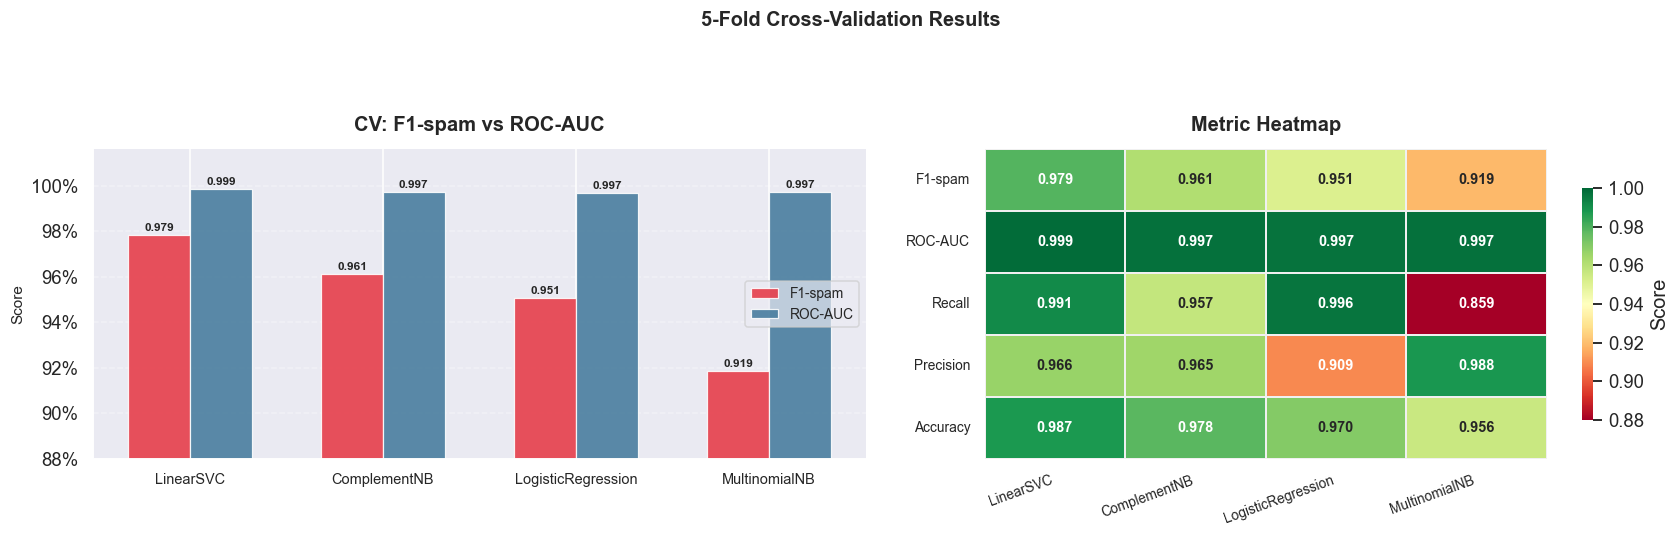

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.1, 1]})

# Grouped bar chart: F1-spam vs ROC-AUC
models = results_df["Model"].tolist()
x = np.arange(len(models))
width = 0.32

b1 = axes[0].bar(x - width/2, results_df["F1-spam"], width, label="F1-spam",
                 color=SPAM_COLOR, alpha=0.88, edgecolor="white", linewidth=0.8)
b2 = axes[0].bar(x + width/2, results_df["ROC-AUC"], width, label="ROC-AUC",
                 color=HAM_COLOR,  alpha=0.88, edgecolor="white", linewidth=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=0, ha="center", fontsize=9.5)
axes[0].set_ylim(0.88, 1.016)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].set_title("CV: F1-spam vs ROC-AUC", fontweight="bold", pad=12)
axes[0].legend(framealpha=0.7, fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].grid(axis="y", alpha=0.35, linestyle="--")
axes[0].set_axisbelow(True)

for bar in [*b1, *b2]:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.0008,
                 f"{h:.3f}", ha="center", va="bottom", fontsize=7.8, fontweight="bold")

# Heatmap
metrics = ["F1-spam", "ROC-AUC", "Recall", "Precision", "Accuracy"]
hm = results_df.set_index("Model")[metrics]
sns.heatmap(
    hm.T, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.88, vmax=1.0, ax=axes[1],
    linewidths=1.0, linecolor="#f0f0f0",
    annot_kws={"size": 9.5, "weight": "bold"},
    cbar_kws={"shrink": 0.75, "label": "Score"},
)
axes[1].set_title("Metric Heatmap", fontweight="bold", pad=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)
axes[1].set_xlabel("")

fig.suptitle("5-Fold Cross-Validation Results", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(pad=2.0)
plt.show()


## 7. Final Evaluation on Test Set

Train the winning model on the **full training set** and evaluate once — and only once — on the held-out test set.

In [30]:
best_clf = CLASSIFIERS[best_name]

# LinearSVC doesn't natively support predict_proba — calibrate it
if isinstance(best_clf, LinearSVC):
    print("Note: LinearSVC wrapped in CalibratedClassifierCV for probability support.")
    best_clf = CalibratedClassifierCV(best_clf, cv=3)

final_pipeline = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_PARAMS)), ("clf", best_clf)])
final_pipeline.fit(X_train, y_train)

y_pred  = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(f"\n{'='*50}")
print(f"  Final model: {best_name}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1-spam : {f1_score(y_test, y_pred):.4f}")

Note: LinearSVC wrapped in CalibratedClassifierCV for probability support.

  Final model: LinearSVC
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       918
        spam       0.99      0.98      0.99       375

    accuracy                           0.99      1293
   macro avg       0.99      0.99      0.99      1293
weighted avg       0.99      0.99      0.99      1293

ROC-AUC : 0.9990
F1-spam : 0.9866


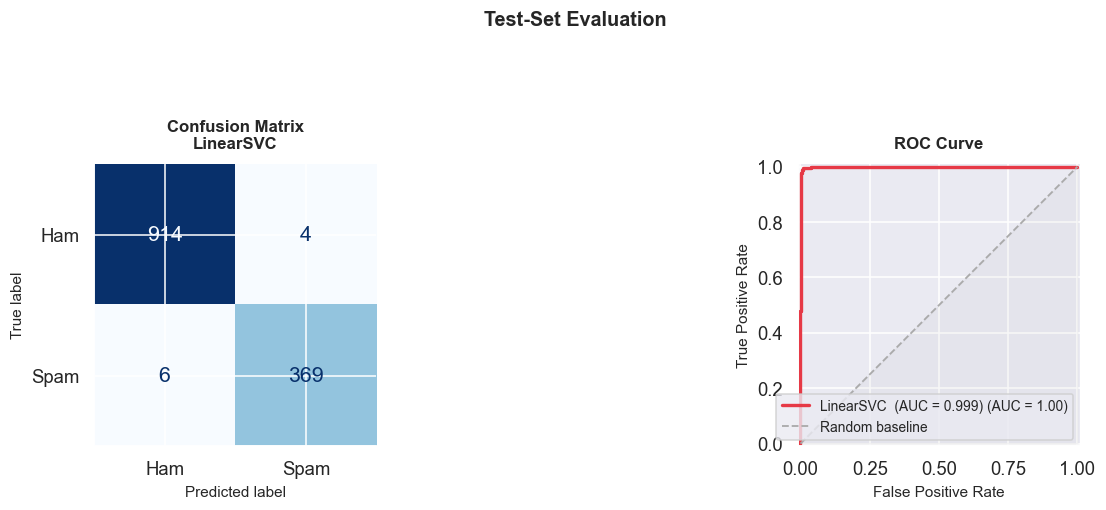

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Ham", "Spam"],
    cmap="Blues", colorbar=False, ax=axes[0],
    text_kw={"fontsize": 14},
)
axes[0].set_title(f"Confusion Matrix\n{best_name}", fontweight="bold", fontsize=11, pad=10)
axes[0].set_xlabel("Predicted label", fontsize=10)
axes[0].set_ylabel("True label", fontsize=10)

# ROC curve
auc_score = roc_auc_score(y_test, y_proba)
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f"{best_name}  (AUC = {auc_score:.3f})",
    color=SPAM_COLOR, linewidth=2.2, ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], "--", color="#aaaaaa", linewidth=1.2, label="Random baseline")
axes[1].fill_between([0, 1], [0, 1], alpha=0.05, color="grey")
axes[1].set_title("ROC Curve", fontweight="bold", fontsize=11, pad=10)
axes[1].legend(loc="lower right", fontsize=9, framealpha=0.8)
axes[1].set_xlabel("False Positive Rate", fontsize=10)
axes[1].set_ylabel("True Positive Rate", fontsize=10)

fig.suptitle("Test-Set Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout(pad=2.5)
plt.show()


In [32]:
# Top discriminative tokens
tfidf_step    = final_pipeline.named_steps["tfidf"]
clf_step      = final_pipeline.named_steps["clf"]
feature_names = np.array(tfidf_step.get_feature_names_out())

coef = None
if hasattr(clf_step, "coef_"):
    coef = clf_step.coef_[0] if clf_step.coef_.ndim > 1 else clf_step.coef_
elif hasattr(clf_step, "estimators_"):
    inner = clf_step.estimators_[0]
    if hasattr(inner, "coef_"):
        coef = inner.coef_[0] if inner.coef_.ndim > 1 else inner.coef_
elif hasattr(clf_step, "feature_log_prob_"):
    coef = clf_step.feature_log_prob_[1] - clf_step.feature_log_prob_[0]

if coef is not None:
    n = 20
    top_spam_idx = np.argsort(coef)[-n:][::-1]
    top_ham_idx  = np.argsort(coef)[:n]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, idx, color, title in [
        (axes[0], top_spam_idx, SPAM_COLOR, f"Top {n} Spam Tokens"),
        (axes[1], top_ham_idx,  HAM_COLOR,  f"Top {n} Ham Tokens"),
    ]:
        tokens = feature_names[idx]
        scores = coef[idx]
        ax.barh(tokens[::-1], scores[::-1], color=color, alpha=0.85, edgecolor="none")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Coefficient / log-prob ratio")
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

    fig.suptitle(f"Most Discriminative Tokens — {best_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Token importance plot not available for this classifier.")

Token importance plot not available for this classifier.


## 8. Save Model Artefacts

In [33]:
# Save the complete sklearn Pipeline (vectorizer + classifier bundled)
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Pipeline saved -> {MODEL_PATH}")

cv_results_path = MODELS_DIR / "cv_results.csv"
results_df.to_csv(cv_results_path, index=False)
print(f"CV results saved -> {cv_results_path}")

Pipeline saved -> ..\models\spam_detector_model.pkl
CV results saved -> ..\models\cv_results.csv


## 9. Inference — Predict New Emails

In [34]:
def predict_email(text: str, pipeline=None) -> dict:
    """Classify a raw email as spam or ham.

    Parameters
    ----------
    text:
        Raw email text.
    pipeline:
        Fitted sklearn Pipeline. Loads from MODEL_PATH if None.

    Returns
    -------
    dict with keys: label, is_spam, spam_probability, clean_text
    """
    if pipeline is None:
        pipeline = joblib.load(MODEL_PATH)

    clean     = preprocess_text(text)
    label_num = int(pipeline.predict([clean])[0])
    proba     = float(pipeline.predict_proba([clean])[0][1])

    return {
        "label":            "SPAM" if label_num else "HAM",
        "is_spam":          bool(label_num),
        "spam_probability": proba,
        "clean_text":       clean,
    }


test_emails = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize NOW!",
    "Hi John, please find the meeting notes from yesterday. Let me know if you have questions.",
    "URGENT! Your bank account has been compromised. Verify immediately at www.secure-login.net",
    "Can you send me the Q3 sales report when you get a chance? Thanks!",
    "Earn $5000 a week working from home! No experience needed. Limited slots — ACT NOW!",
]

print(f"{'Label':<7} {'P(spam)':>8}  Email")
print("-" * 80)
for email in test_emails:
    result = predict_email(email, pipeline=final_pipeline)
    icon = "SPAM" if result["is_spam"] else "HAM "
    print(f"{icon}   {result['spam_probability']:>7.1%}  {email[:65]}")

Label    P(spam)  Email
--------------------------------------------------------------------------------
SPAM     98.7%  Congratulations! You've won a FREE iPhone. Click here to claim yo
HAM       0.5%  Hi John, please find the meeting notes from yesterday. Let me kno
SPAM     99.9%  URGENT! Your bank account has been compromised. Verify immediatel
HAM      13.5%  Can you send me the Q3 sales report when you get a chance? Thanks
SPAM     62.6%  Earn $5000 a week working from home! No experience needed. Limite


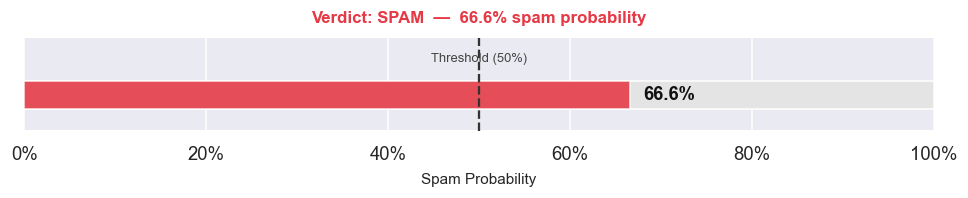

Email   : You have been selected for an exclusive offer. Call 1-800-FREE now!
Clean   : select exclus offer call 1 800 free
Label   : SPAM
P(spam) : 0.6655


In [35]:
# Probability gauge for a custom email
your_email = "You have been selected for an exclusive offer. Call 1-800-FREE now!"

result = predict_email(your_email, pipeline=final_pipeline)
bar_color = SPAM_COLOR if result["is_spam"] else HAM_COLOR
p = result["spam_probability"]

fig, ax = plt.subplots(figsize=(9, 2.0))

# Background track
ax.barh([0], [1.0], height=0.42, color="#e4e4e4", zorder=1)
# Filled portion
ax.barh([0], [p], height=0.42, color=bar_color, alpha=0.88, zorder=2)
# Decision threshold
ax.axvline(0.5, color="#333", linewidth=1.5, linestyle="--", zorder=3)
ax.text(0.5, 0.72, "Threshold (50%)", ha="center", va="bottom", fontsize=8.5,
        color="#444", transform=ax.get_xaxis_transform())

# Probability label
label_x = p + 0.015 if p < 0.9 else p - 0.015
label_ha = "left" if p < 0.9 else "right"
ax.text(label_x, 0, f"{p:.1%}", va="center", ha=label_ha,
        fontsize=12, fontweight="bold", color="#111", zorder=4)

ax.set_xlim(0, 1)
ax.set_ylim(-0.55, 0.85)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_yticks([])
ax.set_xlabel("Spam Probability", fontsize=10, labelpad=6)
ax.set_title(
    f"Verdict: {result['label']}  —  {p:.1%} spam probability",
    fontweight="bold", color=bar_color, fontsize=11, pad=10
)
for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Email   : {your_email}")
print(f"Clean   : {result['clean_text']}")
print(f"Label   : {result['label']}")
print(f"P(spam) : {result['spam_probability']:.4f}")
